In [6]:
from posterior_manifold import FisherLogPosteriorManifold, PosteriorManifold
import matplotlib.pyplot as plt
from conditional_gmm import ConditionalGMM
import torch
import numpy as np
from geometry_tools import scalerot_to_cov, plot_2d_gmm

In [2]:
PLOT_WIDTH = 500
PLOT_HEIGHT = 500
PLOT_DPI = 100
PLOT_COMP_RESOLUTION = 100
xbounds, ybounds = [-2, 2], [-2, 2]
X_c, Y_c = torch.linspace(*xbounds, PLOT_COMP_RESOLUTION), torch.linspace(*ybounds, PLOT_COMP_RESOLUTION) #type:ignore
grid_c = torch.stack(torch.meshgrid(X_c, Y_c, indexing='xy'), dim=-1)

In [3]:
means = torch.tensor((
    (0.85, 0.85),
    (-0.85, 0.85),
    (-0.85, -0.85),
    (0.85, -0.85)
), dtype=torch.float32)
scales = torch.tensor((
    (0.4, 0.4),
    (0.4, 0.4),
    (0.4, 0.4),
    (0.4, 0.4)
), dtype=torch.float32).sqrt()
rots = torch.tensor((0, 0, 0, 0), dtype=torch.float32)

gmm = ConditionalGMM(2, 4, means=means.cuda(), covs=scalerot_to_cov(scales, rots).cuda())

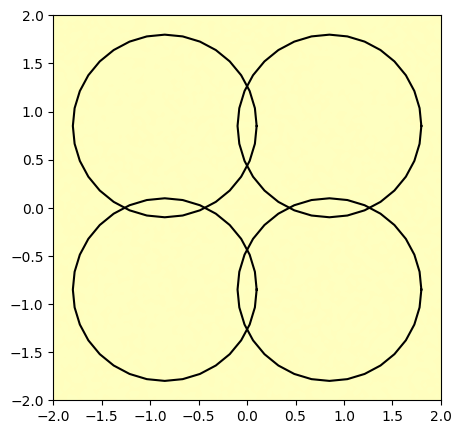

In [8]:
M = FisherLogPosteriorManifold(gmm.log_posterior)
ric_grid = torch.clamp(M.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)

plt.figure(figsize=(PLOT_WIDTH/PLOT_DPI, PLOT_HEIGHT/PLOT_DPI), dpi=PLOT_DPI)
plt.contourf(X_c, Y_c, ric_grid, cmap='RdYlBu', levels=20, vmin=-5, vmax=5)
plot_2d_gmm(gmm.means.cpu(), gmm.covs.cpu())
plt.show()

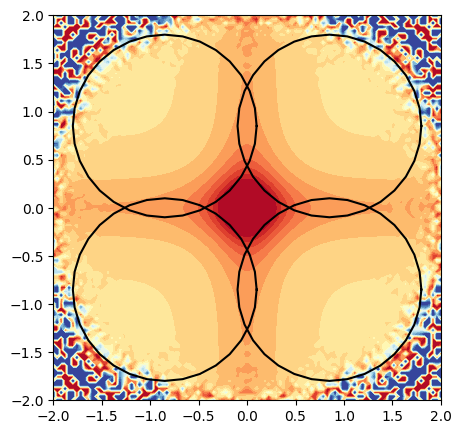

In [9]:
M = PosteriorManifold(gmm.posterior)
ric_grid = torch.clamp(M.ric(grid_c.cuda()).detach().cpu(), min=-5, max=5)

plt.figure(figsize=(PLOT_WIDTH/PLOT_DPI, PLOT_HEIGHT/PLOT_DPI), dpi=PLOT_DPI)
plt.contourf(X_c, Y_c, ric_grid, cmap='RdYlBu', levels=20, vmin=-5, vmax=5)
plot_2d_gmm(gmm.means.cpu(), gmm.covs.cpu())
plt.show()